In [1]:
!pip install timm
!pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 81.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=b403e5832c446eee9aa37d3dc3f22c10349c749d94fbab83f6cc1990a1594a96
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
from google.colab import drive
import zipfile
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Extract the dataset to Colab's fast local storage
zip_path = '/content/drive/MyDrive/Indicraft-ethinicwear.zip'
extract_path = '/content/dataset'

# Only extract if it hasn't been extracted yet
if not os.path.exists(extract_path):
    print("Extracting dataset... this might take a minute.")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Done extracting!")
else:
    print("Dataset already extracted in this session.")

print("Files inside:", os.listdir(extract_path))


Mounted at /content/drive
Extracting dataset... this might take a minute.
Done extracting!
Files inside: ['__MACOSX', 'Indicraft-ethinicwear']


In [3]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define Standard ImageNet-style transforms
# For training: Resize, augment slightly, convert to tensor, and normalize
# For validation: Just resize, convert to tensor, and normalize
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 2. Point to your train and val image folders
# Adjust the path if your unzipped folder name is slightly different
data_dir = '/content/dataset/Indicraft-ethinicwear/images'
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')

# 3. Create PyTorch Datasets
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, data_transforms['val'])
}

# 4. Create DataLoaders (this groups images into batches of 32 for the GPU)
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False, num_workers=2)
}

# 5. Extract system stats
class_names = image_datasets['train'].classes
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

print(f"✅ Classes Found: {class_names}")
print(f"✅ Number of classes: {len(class_names)}")
print(f"✅ Training images: {dataset_sizes['train']}")
print(f"✅ Validation images: {dataset_sizes['val']}")

# Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")


✅ Classes Found: ['Banarasi_Silk', 'Bandhani', 'Blouse', 'Kanjeevaram_Saree', 'Kurti', 'Lehenga', "Men's_kurta", 'Nehru_Jacket', 'Palazzo', 'Salwar_kameez', 'Saree', 'Sherwani']
✅ Number of classes: 12
✅ Training images: 2254
✅ Validation images: 483
🚀 Using device: cuda


In [4]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define Standard ImageNet-style transforms
# For training: Resize, augment slightly, convert to tensor, and normalize
# For validation: Just resize, convert to tensor, and normalize
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 2. Point to your train and val image folders
# Adjust the path if your unzipped folder name is slightly different
data_dir = '/content/dataset/Indicraft-ethinicwear/images'
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')

# 3. Create PyTorch Datasets
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, data_transforms['val'])
}

# 4. Create DataLoaders (this groups images into batches of 32 for the GPU)
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False, num_workers=2)
}

# 5. Extract system stats
class_names = image_datasets['train'].classes
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

print(f"✅ Classes Found: {class_names}")
print(f"✅ Number of classes: {len(class_names)}")
print(f"✅ Training images: {dataset_sizes['train']}")
print(f"✅ Validation images: {dataset_sizes['val']}")

# Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")


✅ Classes Found: ['Banarasi_Silk', 'Bandhani', 'Blouse', 'Kanjeevaram_Saree', 'Kurti', 'Lehenga', "Men's_kurta", 'Nehru_Jacket', 'Palazzo', 'Salwar_kameez', 'Saree', 'Sherwani']
✅ Number of classes: 12
✅ Training images: 2254
✅ Validation images: 483
🚀 Using device: cuda


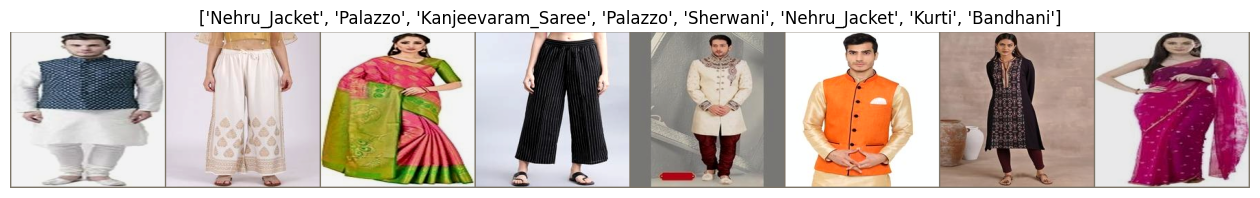

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(inp, title=None):
    """Utility function to display a normalized Tensor as a matplotlib image."""
    inp = inp.numpy().transpose((1, 2, 0))
    # Undo ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)

    plt.figure(figsize=(16, 6))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Get one batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid containing the first 8 images of the batch
out = torchvision.utils.make_grid(inputs[:8])
imshow(out, title=[class_names[x] for x in classes[:8]])


In [6]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

def create_and_train_probe(model_name, num_classes, dataloaders, device, num_epochs=3):
    print(f"\n--- Starting Linear Probing for {model_name} ---")

    # 1. Load Pretrained Model Architecture
    if model_name == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    elif model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    elif model_name == 'resnet152':
        model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)

    # 2. Freeze the backbone (Zero backbone training! Pure representation test)
    for param in model.parameters():
        param.requires_grad = False

    num_ftrs = model.fc.in_features
    # 3. Replace the final layer (this layer automatically has requires_grad=True)
    model.fc = nn.Linear(num_ftrs, num_classes)
    model = model.to(device)

    # 4. Setup Optimizer (only updating the weights of the fc layer we just added)
    optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # 5. Quick Train Loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in dataloaders['train']:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/dataset_sizes['train']:.4f}")

    return model

# Run the experiment across the 3 depths!
num_classes = len(class_names)
model_18 = create_and_train_probe('resnet18', num_classes, dataloaders, device)
model_50 = create_and_train_probe('resnet50', num_classes, dataloaders, device)
model_152 = create_and_train_probe('resnet152', num_classes, dataloaders, device)



--- Starting Linear Probing for resnet18 ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]


Epoch 1/3 - Loss: 1.7596
Epoch 2/3 - Loss: 1.0013
Epoch 3/3 - Loss: 0.7873

--- Starting Linear Probing for resnet50 ---
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


Epoch 1/3 - Loss: 1.4817
Epoch 2/3 - Loss: 0.7941
Epoch 3/3 - Loss: 0.6455

--- Starting Linear Probing for resnet152 ---
Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:01<00:00, 183MB/s]


Epoch 1/3 - Loss: 1.4224
Epoch 2/3 - Loss: 0.7498
Epoch 3/3 - Loss: 0.5961


In [7]:
import numpy as np

def evaluate_per_class(model, dataloaders, class_names, device):
    model.eval()
    class_correct = list(0. for i in range(len(class_names)))
    class_total = list(0. for i in range(len(class_names)))

    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            c = (predicted == labels).squeeze()

            # Handle batch sizes of 1 gracefully
            if c.dim() == 0:
                c = c.unsqueeze(0)

            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    accuracies = {class_names[i]: 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
                  for i in range(len(class_names))}
    return accuracies

print("\nGenerating Class-wise Accuracy Table...")
acc_18 = evaluate_per_class(model_18, dataloaders, class_names, device)
acc_50 = evaluate_per_class(model_50, dataloaders, class_names, device)
acc_152 = evaluate_per_class(model_152, dataloaders, class_names, device)

print(f"\n{'Class Name':<20} | {'Res-18 (Shallow)':<18} | {'Res-50 (Mid)':<18} | {'Res-152 (Deep)':<18}")
print("-" * 80)
for cls in class_names:
    print(f"{cls:<20} | {acc_18[cls]:>5.1f}%             | {acc_50[cls]:>5.1f}%             | {acc_152[cls]:>5.1f}%")



Generating Class-wise Accuracy Table...

Class Name           | Res-18 (Shallow)   | Res-50 (Mid)       | Res-152 (Deep)    
--------------------------------------------------------------------------------
Banarasi_Silk        |   4.5%             |   0.0%             |   4.5%
Bandhani             |  10.5%             |  42.1%             |  15.8%
Blouse               |  95.6%             |  91.1%             |  93.3%
Kanjeevaram_Saree    |   0.0%             |  45.0%             |  20.0%
Kurti                |  80.8%             |  84.6%             |  86.5%
Lehenga              |  74.5%             |  88.2%             |  76.5%
Men's_kurta          |  77.8%             |  92.6%             |  77.8%
Nehru_Jacket         |  78.8%             |  78.8%             |  78.8%
Palazzo              |  89.1%             |  91.3%             |  93.5%
Salwar_kameez        |  94.2%             |  84.6%             |  94.2%
Saree                |  88.9%             |  73.3%             |  93.3%
S

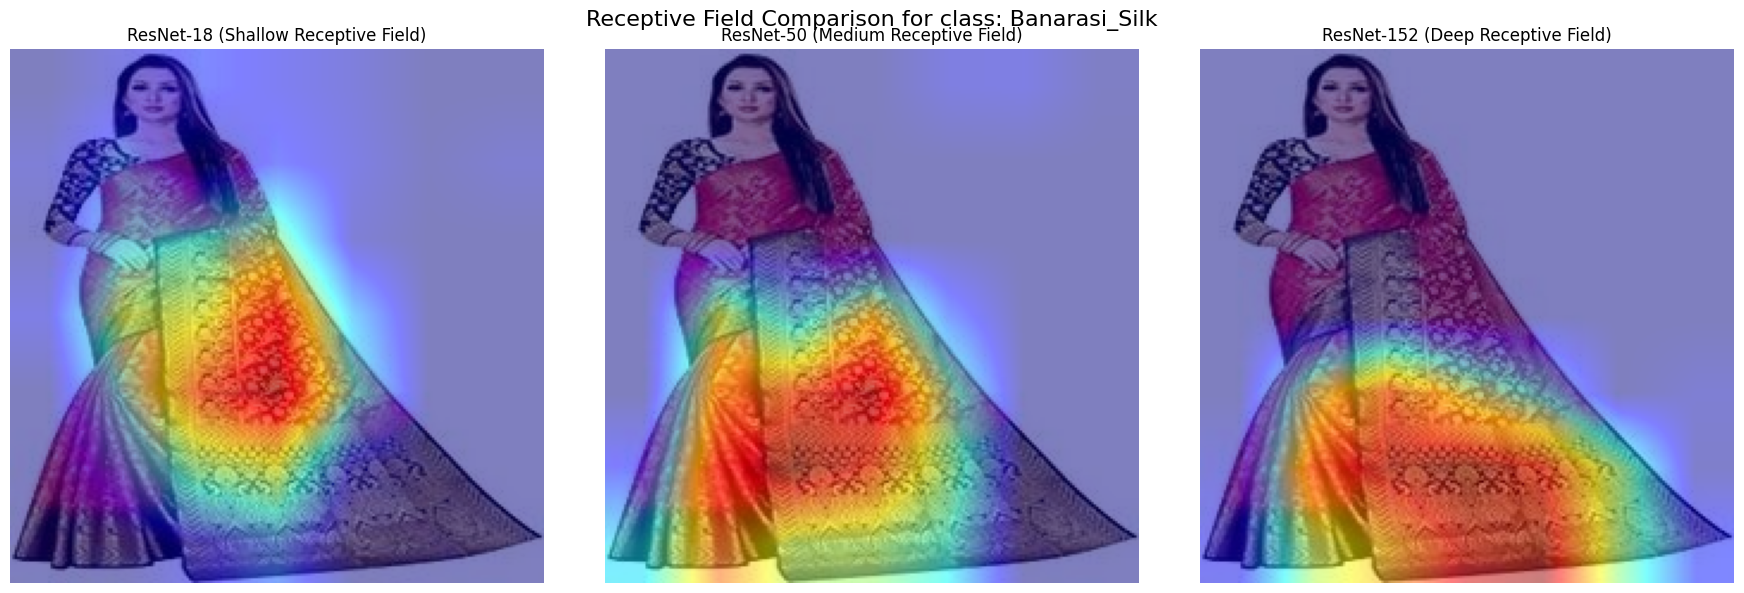

In [9]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

def get_gradcam_overlay(model, target_layer, image_tensor, label_idx):
    # FIX: Unfreeze the model temporarily so Grad-CAM can calculate the backward gradients!
    for param in model.parameters():
        param.requires_grad = True

    # Ensure model is in eval mode
    model.eval()

    # Initialize the GradCAM plugin
    cam = GradCAM(model=model, target_layers=[target_layer])

    # Tell CAM to analyze the regions responsible for this specific label category
    targets = [ClassifierOutputTarget(label_idx)]

    # Extract the raw heatmap
    grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0).to(device), targets=targets)[0, :]

    # Format the original tensor back into an image
    img = image_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    # Lay the heatmap over the original image
    return show_cam_on_image(img, grayscale_cam, use_rgb=True)

# Grab one batch from validation and look at the first image
inputs, labels = next(iter(dataloaders['val']))
idx = 0  # Change this to look at a different image!
input_img = inputs[idx]
label = labels[idx].item()

plt.figure(figsize=(18, 6))
plt.suptitle(f"Receptive Field Comparison for class: {class_names[label]}", fontsize=16)

# 1. ResNet-18 Activation Region (Notice how local/blocky it is?)
plt.subplot(1, 3, 1)
vis_18 = get_gradcam_overlay(model_18, model_18.layer4[-1], input_img, label)
plt.imshow(vis_18)
plt.title("ResNet-18 (Shallow Receptive Field)")
plt.axis('off')

# 2. ResNet-50 Activation Region
plt.subplot(1, 3, 2)
vis_50 = get_gradcam_overlay(model_50, model_50.layer4[-1], input_img, label)
plt.imshow(vis_50)
plt.title("ResNet-50 (Medium Receptive Field)")
plt.axis('off')

# 3. ResNet-152 Activation Region (Notice how it sees the whole global structure?)
plt.subplot(1, 3, 3)
vis_152 = get_gradcam_overlay(model_152, model_152.layer4[-1], input_img, label)
plt.imshow(vis_152)
plt.title("ResNet-152 (Deep Receptive Field)")
plt.axis('off')

plt.tight_layout()
plt.show()


In [10]:
import timm
import torch.nn as nn
import torch.optim as optim
import copy

def create_vit_probe(num_classes, dataloaders, device):
    print("--- Training Linear Probe for ViT-Base ---")
    # Load timm's standard ViT (Base size, 16x16 patches, 224x224 input)
    model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)

    # Freeze the entire backbone
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze only the final classification head
    for param in model.head.parameters():
        param.requires_grad = True

    model = model.to(device)
    optimizer = optim.Adam(model.head.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Quick Train Loop
    for epoch in range(3):
        model.train()
        running_loss = 0.0
        for inputs, labels in dataloaders['train']:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        print(f"Epoch {epoch+1}/3 - Loss: {running_loss/dataset_sizes['train']:.4f}")

    return model

vit_model = create_vit_probe(num_classes, dataloaders, device)


--- Training Linear Probe for ViT-Base ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch 1/3 - Loss: 0.8497
Epoch 2/3 - Loss: 0.4211
Epoch 3/3 - Loss: 0.3429


In [11]:
def ablate_vit_head(model, layer_idx, head_idx):
    """
    Performs 'surgery' on the ViT by zeroing out the Query and Key weights
    for a specific attention head. This forces the q @ k attention scores to be 0,
    turning the Softmax attention vector into a flat uniform distribution (1/N).
    """
    h_dim = 64  # vit_base has 768 total dimensions / 12 heads = 64 dim per head

    # Q weights are stored in the first 768 rows of the QKV projection
    q_start = head_idx * h_dim
    q_end = (head_idx + 1) * h_dim

    # K weights are stored in the middle 768 rows
    k_start = 768 + (head_idx * h_dim)
    k_end = 768 + ((head_idx + 1) * h_dim)

    # Zero out the selected Q and K weights entirely
    with torch.no_grad():
        model.blocks[layer_idx].attn.qkv.weight[q_start:q_end, :] = 0
        model.blocks[layer_idx].attn.qkv.weight[k_start:k_end, :] = 0

        # Zero the bias components as well
        if model.blocks[layer_idx].attn.qkv.bias is not None:
             model.blocks[layer_idx].attn.qkv.bias[q_start:q_end] = 0
             model.blocks[layer_idx].attn.qkv.bias[k_start:k_end] = 0

def evaluate_surgery(model, dataloaders, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Let's get our Baseline (No Surgery) established
print("\nEvaluating Baseline ViT (No heads masked)...")
baseline_acc = evaluate_surgery(vit_model, dataloaders, device)
print(f"Baseline Accuracy: {baseline_acc:.2f}%\n")



Evaluating Baseline ViT (No heads masked)...
Baseline Accuracy: 84.47%



--- Firing sweep across all 12 heads of Layer 10 ---
Masked Head  0 -> Acc: 84.06% | Performance Drop:  0.41%
Masked Head  1 -> Acc: 84.06% | Performance Drop:  0.41%
Masked Head  2 -> Acc: 83.23% | Performance Drop:  1.24%
Masked Head  3 -> Acc: 84.68% | Performance Drop: -0.21%
Masked Head  4 -> Acc: 84.06% | Performance Drop:  0.41%
Masked Head  5 -> Acc: 84.47% | Performance Drop:  0.00%
Masked Head  6 -> Acc: 84.27% | Performance Drop:  0.21%
Masked Head  7 -> Acc: 84.47% | Performance Drop:  0.00%
Masked Head  8 -> Acc: 83.44% | Performance Drop:  1.04%
Masked Head  9 -> Acc: 83.85% | Performance Drop:  0.62%
Masked Head 10 -> Acc: 83.44% | Performance Drop:  1.04%
Masked Head 11 -> Acc: 84.27% | Performance Drop:  0.21%


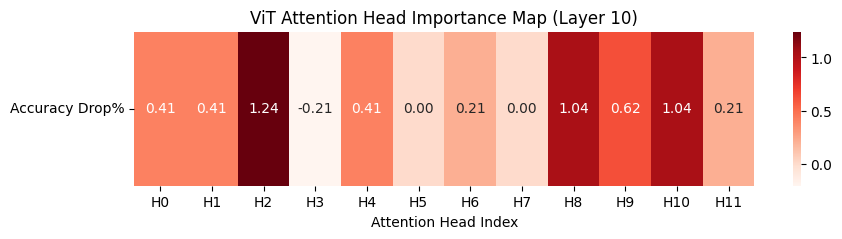

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

layer_to_test = 10
print(f"--- Firing sweep across all 12 heads of Layer {layer_to_test} ---")
head_drops = []

# Loop through Heads 0 to 11
for head_id in range(12):
    # Make a fresh copy of the model so we only test ONE head at a time
    test_model = copy.deepcopy(vit_model)

    # Preform the ablation surgery
    ablate_vit_head(test_model, layer_idx=layer_to_test, head_idx=head_id)

    # Evaluate the damaged model
    acc = evaluate_surgery(test_model, dataloaders, device)
    drop = baseline_acc - acc
    head_drops.append(drop)

    print(f"Masked Head {head_id:2d} -> Acc: {acc:>5.2f}% | Performance Drop: {drop:>5.2f}%")

# Construct the Deliverable Heatmap!
plt.figure(figsize=(10, 2))
sns.heatmap([head_drops], annot=True, fmt=".2f", cmap='Reds', xticklabels=[f"H{i}" for i in range(12)], yticklabels=['Accuracy Drop%'])
plt.title(f"ViT Attention Head Importance Map (Layer {layer_to_test})")
plt.xlabel("Attention Head Index")
plt.yticks(rotation=0)
plt.show()

# NOTE: The heads with massive drops (dark red) are highly critical features.
# Heads with negative drops actually HURT the model, meaning destroying them improved performance!


In [14]:
import time
import torch.nn as nn
import torch.optim as optim
from torchvision import models

def get_resnet_strategy(strategy_name, num_classes):
    # Spin up a fresh pre-trained ResNet-18
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Helper function to bulk-freeze/unfreeze model components
    def set_grad(params, requires_grad):
        for param in params:
            param.requires_grad = requires_grad

    if strategy_name == "Strategy A (Unfreeze All)":
        set_grad(model.parameters(), True)

    elif strategy_name == "Strategy B (Freeze Early)":
        set_grad(model.parameters(), True)
        # Freeze the early feature extractors
        set_grad(model.conv1.parameters(), False)
        set_grad(model.bn1.parameters(), False)
        set_grad(model.layer1.parameters(), False)
        set_grad(model.layer2.parameters(), False)

    elif strategy_name == "Strategy C (Freeze Late)":
        set_grad(model.parameters(), True)
        # Freeze the deep semantic extractors
        set_grad(model.layer3.parameters(), False)
        set_grad(model.layer4.parameters(), False)

    elif strategy_name == "Strategy D (Linear Probe)":
        # Freeze everything
        set_grad(model.parameters(), False)

    # ALWAYS replace and unfreeze the final classification head
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    set_grad(model.fc.parameters(), True)

    return model


In [15]:
def train_and_eval_strategy(model, strategy_name, dataloaders, device, num_epochs=4):
    print(f"\n🚀 Running: {strategy_name}")
    model = model.to(device)

    # PyTorch trick: ONLY pass the un-frozen parameters to the Adam optimizer to save memory!
    params_to_update = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(params_to_update, lr=0.001)
    criterion = nn.CrossEntropyLoss()

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in dataloaders['train']:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

    train_time = time.time() - start_time

    # Evaluate Validation Accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    print(f"✅ Finished! Time: {train_time:.1f} sec | Val Accuracy: {val_acc:.2f}%")
    return train_time, val_acc

# Let's fire the 4 experiments!
strategies = [
    "Strategy A (Unfreeze All)",
    "Strategy B (Freeze Early)",
    "Strategy C (Freeze Late)",
    "Strategy D (Linear Probe)"
]

results = []
for name in strategies:
    model = get_resnet_strategy(name, num_classes)
    time_taken, acc = train_and_eval_strategy(model, name, dataloaders, device, num_epochs=4)
    results.append({'Strategy': name, 'Time (s)': time_taken, 'Accuracy (%)': acc})



🚀 Running: Strategy A (Unfreeze All)
✅ Finished! Time: 43.0 sec | Val Accuracy: 78.88%

🚀 Running: Strategy B (Freeze Early)
✅ Finished! Time: 38.5 sec | Val Accuracy: 83.02%

🚀 Running: Strategy C (Freeze Late)
✅ Finished! Time: 38.4 sec | Val Accuracy: 78.67%

🚀 Running: Strategy D (Linear Probe)
✅ Finished! Time: 34.6 sec | Val Accuracy: 76.40%


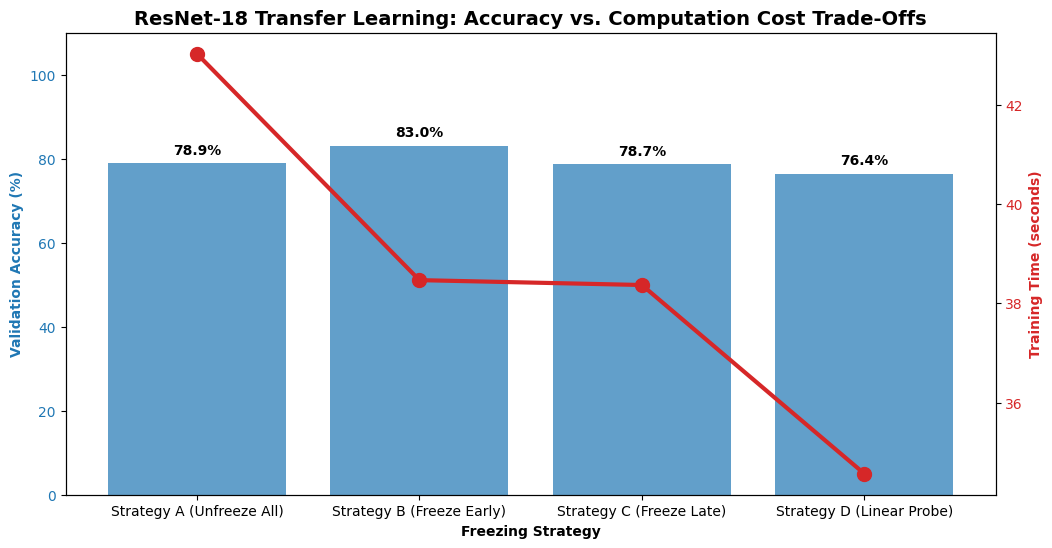

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the Accuracy as Blue Bars
color = 'tab:blue'
ax1.set_xlabel('Freezing Strategy', fontweight='bold')
ax1.set_ylabel('Validation Accuracy (%)', color=color, fontweight='bold')
bars = ax1.bar(df['Strategy'], df['Accuracy (%)'], color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)

# Put text labels on the bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot the Training Time as a Red Line
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Training Time (seconds)', color=color, fontweight='bold')
ax2.plot(df['Strategy'], df['Time (s)'], color=color, marker='o', linewidth=3, markersize=10)
ax2.tick_params(axis='y', labelcolor=color)

# Increase upper buffer so labels aren't cut off
ax1.set_ylim(0, 110)

plt.title("ResNet-18 Transfer Learning: Accuracy vs. Computation Cost Trade-Offs", fontsize=14, fontweight='bold')
plt.show()
